# Weibull Analysis for Wind Extremes in The Philippines

In [1]:
# Import and path

from glob import glob
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.stats import weibull_min

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../reports", exist_ok=True)


In [2]:
# Load in Multi-Year ERA5 Files

paths = sorted(glob("../data/raw/era5_u10v10_*_PH.nc"))
print("Found files:", len(paths))
for p in paths:
    print(" -", p)

ds = xr.open_mfdataset(paths, combine="by_coords", chunks={"time": 200})
ds

Found files: 5
 - ../data/raw/era5_u10v10_2019_PH.nc
 - ../data/raw/era5_u10v10_2020_PH.nc
 - ../data/raw/era5_u10v10_2021_PH.nc
 - ../data/raw/era5_u10v10_2022_PH.nc
 - ../data/raw/era5_u10v10_2023_PH.nc


<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 43824, latitude: 81, longitude: 49)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2019-01-01 ... 2023-12-31T2...
    expver      (valid_time) <U4 701kB dask.array<chunksize=(8760,), meta=np.ndarray>
  * latitude    (latitude) float64 648B 22.0 21.75 21.5 21.25 ... 2.5 2.25 2.0
  * longitude   (longitude) float64 392B 116.0 116.2 116.5 ... 127.5 127.8 128.0
    number      int64 8B 0
Data variables:
    u10         (valid_time, latitude, longitude) float32 696MB dask.array<chunksize=(2920, 27, 17), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 696MB dask.array<chunksize=(2920, 27, 17), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-18T00:53 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
# Compute Wind Speed and Assign to DataSet

ds = ds.assign(ws10 = np.sqrt(ds['u10']**2 + ds['v10']**2))
ds['ws10'].attrs['units'] = 'm s-1'
ds['ws10'].attrs['long_name'] = '10m Wind Speed'

# Access windspeed and save to a variable
ws = ds['ws10']

# Inspect Wind Speed Variable
ws

<xarray.DataArray 'ws10' (valid_time: 43824, latitude: 81, longitude: 49)> Size: 696MB
dask.array<sqrt, shape=(43824, 81, 49), dtype=float32, chunksize=(2928, 27, 17), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2019-01-01 ... 2023-12-31T2...
    expver      (valid_time) <U4 701kB dask.array<chunksize=(8760,), meta=np.ndarray>
  * latitude    (latitude) float64 648B 22.0 21.75 21.5 21.25 ... 2.5 2.25 2.0
  * longitude   (longitude) float64 392B 116.0 116.2 116.5 ... 127.5 127.8 128.0
    number      int64 8B 0
Attributes: (12/28)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3969
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s-1
    standard_name:                            unknown
    GRIB_surface:                             0.0
    long_name:                                10m Wind Speed

In [4]:
# Coarsen the Grid for Optimization of Weibull Analysis
ws_c = ws.coarsen(latitude=2, longitude=2, boundary='trim').mean()
ws_c

<xarray.DataArray 'ws10' (valid_time: 43824, latitude: 40, longitude: 24)> Size: 168MB
dask.array<mean_agg-aggregate, shape=(43824, 40, 24), dtype=float32, chunksize=(2928, 13, 8), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2019-01-01 ... 2023-12-31T2...
    expver      (valid_time) <U4 701kB dask.array<chunksize=(8760,), meta=np.ndarray>
  * latitude    (latitude) float64 320B 21.88 21.38 20.88 ... 3.375 2.875 2.375
  * longitude   (longitude) float64 192B 116.1 116.6 117.1 ... 126.6 127.1 127.6
    number      int64 8B 0
Attributes: (12/28)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3969
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m s-1
    standard_name:                            unknown
    GRIB_surface:                             0.0
    long_name:                                10m Wind Speed

In [6]:
# Calculate Basic Statistics on Coarsened Wind (This will be used in the final table outputs)
mean_ws = ws_c.mean('valid_time')
p95_ws = ws_c.quantile(0.95, dim='valid_time')
p99_ws = ws_c.quantile(0.99, dim='valid_time')

mean_ws, p95_ws, p99_ws

(<xarray.DataArray 'ws10' (latitude: 40, longitude: 24)> Size: 4kB
 dask.array<mean_agg-aggregate, shape=(40, 24), dtype=float32, chunksize=(13, 8), chunktype=numpy.ndarray>
 Coordinates:
   * latitude   (latitude) float64 320B 21.88 21.38 20.88 ... 3.375 2.875 2.375
   * longitude  (longitude) float64 192B 116.1 116.6 117.1 ... 126.6 127.1 127.6
     number     int64 8B 0
 Attributes: (12/28)
     GRIB_dataType:                            an
     GRIB_numberOfPoints:                      3969
     GRIB_typeOfLevel:                         surface
     GRIB_stepUnits:                           1
     GRIB_stepType:                            instant
     GRIB_gridType:                            regular_ll
     ...                                       ...
     GRIB_totalNumber:                         0
     GRIB_units:                               m s**-1
     units:                                    m s-1
     standard_name:                            unknown
     GRIB_surface:   

In [7]:
# Helper Functions for Smoothing and Plotting with Gridlines
def smooth_da(da, dlat=0.1, dlon=0.1, method="linear"):
    da_sorted = da.sortby("latitude")
    lat_min, lat_max = float(da_sorted.latitude.min()), float(da_sorted.latitude.max())
    lon_min, lon_max = float(da_sorted.longitude.min()), float(da_sorted.longitude.max())
    new_lat = np.arange(lat_min, lat_max + dlat, dlat)
    new_lon = np.arange(lon_min, lon_max + dlon, dlon)
    return da_sorted.interp(latitude=new_lat, longitude=new_lon, method=method)

def plot_map(da, title, out_png, extent=(116, 128, 2, 22)):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(11, 6.5))
    ax = plt.axes(projection=proj)
    ax.set_extent(extent, crs=proj)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.1)

    gl = ax.gridlines(crs=proj, draw_labels=True, linewidth=0.6, linestyle="--", alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    im = ax.pcolormesh(
        da["longitude"], da["latitude"], da.values,
        transform=proj, shading="gouraud"
    )
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
    cb.set_label(da.attrs.get("units", ""))

    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=250)
    plt.show()
    plt.close(fig)


## Weibull Fitting Function (Cell-by-cell)

Here, we define a function to calculate Weibull(k, c) to wind speed time series at each grid cell

In [8]:
def fit_weibull_maps(ws_da, min_ws=0.2, min_n=500):
    """
    Fit Weibull(k, c) to wind speed time series at each grid cell.
    - min_ws filters near-zeros
    - min_n requires enough samples
    """
    # Filter out areas where wind is near zero
    ws_f = ws_da.where(ws_da > min_ws)

    # Retrieve the latitude and longitudes from previously created object
    lats = ws_f.latitude.values
    lons = ws_f.longitude.values

    # Initialize the domain with null values
    k_map = np.full((len(lats), len(lons)), np.nan)
    c_map = np.full((len(lats), len(lons)), np.nan)

    # Iterate cells and fit Weibull
    for i in range(len(lats)):
        for j in range(len(lons)):
            x = ws_f[:, i, j].values
            x = x[np.isfinite(x)]
            if x.size < min_n:
                continue

            # Fit Weibull; fix loc=0 to keep support v>=0
            k, loc, c = weibull_min.fit(x, floc=0.0)
            k_map[i, j] = k
            c_map[i, j] = c

    # Finally recreate k_map and c_map into a DataArray
    k_da = xr.DataArray(k_map, coords={"latitude": lats, "longitude": lons},
                        dims=("latitude", "longitude"), name="weibull_k")
    c_da = xr.DataArray(c_map, coords={"latitude": lats, "longitude": lons},
                        dims=("latitude", "longitude"), name="weibull_c")

    k_da.attrs["long_name"] = "Weibull shape parameter k"
    c_da.attrs["long_name"] = "Weibull scale parameter c"
    c_da.attrs["units"] = "m s-1"

    return k_da, c_da


## Fit Weibull Maps

In [9]:
# Fit Weibull Maps
k_da, c_da = fit_weibull_maps(ws_c, min_ws = 0.2, min_n = 500)

In [10]:
# Inspect k_da
k_da

<xarray.DataArray 'weibull_k' (latitude: 40, longitude: 24)> Size: 8kB
array([[2.38369222, 2.36444034, 2.35353207, 2.35118071, 2.35434987,
        2.3567393 , 2.41763295, 2.45626958, 2.48109105, 2.51176991,
        2.38304231, 2.43415153, 2.41139532, 2.40271432, 2.43029667,
        2.4485206 , 2.439105  , 2.42558473, 2.42145405, 2.40583341,
        2.38615626, 2.40026709, 2.42180277, 2.43108134],
       [2.33727061, 2.33145704, 2.35398264, 2.37857822, 2.4328989 ,
        2.50243245, 2.59277969, 2.56269459, 2.41167607, 2.34926282,
        2.38576317, 2.41871125, 2.40599518, 2.42972875, 2.44642452,
        2.44030768, 2.41529976, 2.397945  , 2.39618294, 2.38397359,
        2.37581358, 2.38852209, 2.40552683, 2.41869648],
       [2.31288381, 2.30012319, 2.31802647, 2.37197729, 2.43842911,
        2.49064951, 2.46314611, 2.39044032, 2.33322776, 2.34685878,
        2.40009041, 2.40115961, 2.38798331, 2.42426465, 2.43398933,
        2.41743937, 2.38761069, 2.3763928 , 2.37233273, 2.35507878,
        2.34738052, 2.36536964, 2.38067106, 2.39079201],
       [2.29912354, 2.28325551, 2.28382655, 2.32067052, 2.33995853,
        2.33645836, 2.31406214, 2.30015275, 2.32087088, 2.35998062,
        2.38415204, 2.39619642, 2.39117133, 2.40674637, 2.41159137,
        2.39234901, 2.36419805, 2.35917903, 2.36115585, 2.34035127,
        2.3255381 , 2.34119501, 2.35784916, 2.36819245],
...
       [2.12615609, 2.45721995, 2.58251683, 2.44660086, 2.18752935,
        2.13409639, 2.13189423, 2.11174295, 2.06858985, 2.03436825,
        2.00684826, 1.99071778, 1.96793752, 1.94874899, 1.95572423,
        1.96853746, 2.00003791, 2.08189164, 2.20316501, 2.30407009,
        2.30601425, 2.27890171, 2.22518842, 2.1988414 ],
       [2.25865937, 2.45819985, 2.4111693 , 2.21861789, 2.09693189,
        2.09574756, 2.10534376, 2.08716272, 2.04600462, 2.02859221,
        2.01962272, 2.00903513, 1.98664183, 1.94018843, 1.92383791,
        1.94706296, 1.99249478, 2.0967535 , 2.23349071, 2.30058526,
        2.2806503 , 2.25533408, 2.20429349, 2.1747885 ],
       [2.13390141, 2.42290414, 2.23058399, 2.29797407, 2.148837  ,
        2.05858764, 2.06590997, 2.0548369 , 2.02235554, 2.01155653,
        1.98736483, 1.96896943, 1.96172757, 1.93383536, 1.91729593,
        1.91452493, 1.96036856, 2.08858239, 2.25810632, 2.28643144,
        2.27080928, 2.23955178, 2.17879131, 2.11915174],
       [2.04237445, 2.42831232, 2.06539362, 2.27429737, 2.18975913,
        2.06497845, 2.05637093, 2.00443451, 1.97592035, 1.96907458,
        1.92929523, 1.90821931, 1.94158924, 1.93027845, 1.90741367,
        1.86961134, 1.90562808, 2.02499259, 2.28860159, 2.3152985 ,
        2.29127808, 2.23805219, 2.1409038 , 2.10294585]])
Coordinates:
  * latitude   (latitude) float64 320B 21.88 21.38 20.88 ... 3.375 2.875 2.375
  * longitude  (longitude) float64 192B 116.1 116.6 117.1 ... 126.6 127.1 127.6
Attributes:
    long_name:  Weibull shape parameter k

In [11]:
# Inspect c_da
c_da

<xarray.DataArray 'weibull_c' (latitude: 40, longitude: 24)> Size: 8kB
array([[8.517198  , 8.68757106, 8.75421359, 8.68580267, 8.53993904,
        8.13421869, 7.595065  , 7.05397253, 7.07949627, 8.4269135 ,
        9.55090146, 9.14059846, 8.85923927, 8.69571494, 8.6212906 ,
        8.53478184, 8.48074802, 8.42303925, 8.35205047, 8.31241001,
        8.25396034, 8.20172724, 8.13402017, 8.07784522],
       [8.5612995 , 8.65393141, 8.65663651, 8.57736268, 8.41106061,
        8.1633011 , 8.02137137, 8.25356064, 8.9264872 , 9.51455952,
        9.43158839, 9.04761277, 8.80492687, 8.68327308, 8.62521108,
        8.54452641, 8.46941258, 8.37767143, 8.33980247, 8.27546205,
        8.23244963, 8.18396648, 8.12303262, 8.07191736],
       [8.55262021, 8.59052649, 8.59108228, 8.56506729, 8.50084108,
        8.50022495, 8.63997321, 8.97174633, 9.30565451, 9.39348035,
        9.25134669, 8.96669814, 8.75693214, 8.68201363, 8.55538368,
        8.454271  , 8.38512516, 8.32588848, 8.25729486, 8.20848996,
        8.18069423, 8.12487992, 8.08453765, 8.02387143],
       [8.57401259, 8.60635418, 8.61408789, 8.63780118, 8.69570326,
        8.8027382 , 8.97810586, 9.15530117, 9.22890352, 9.23665613,
        9.13291362, 8.94585579, 8.76007014, 8.58682567, 8.4482014 ,
        8.34979418, 8.25356785, 8.19216425, 8.15191079, 8.12928609,
        8.08853568, 8.05746356, 8.01544714, 7.96441248],
...
       [0.94985119, 1.04275358, 1.14606286, 2.00508127, 3.23334066,
        3.72114497, 3.90157531, 3.89470226, 3.83114369, 3.75612717,
        3.68262233, 3.65896078, 3.69153674, 3.78407483, 3.91981659,
        4.09037248, 4.31936623, 4.61816949, 4.95757384, 5.20436778,
        5.25871018, 5.18993429, 5.27782851, 5.16352455],
       [1.00486118, 1.0116833 , 1.28576183, 2.74517294, 3.39820974,
        3.72566199, 3.88851703, 3.89371314, 3.84316503, 3.76740183,
        3.71412849, 3.7076343 , 3.77049219, 3.86162819, 3.95032492,
        4.07518108, 4.25893246, 4.50088641, 4.85043295, 5.18118115,
        5.22972925, 5.2188287 , 5.16800282, 5.03382696],
       [0.99656253, 0.9544957 , 1.13736859, 1.96351422, 3.36431972,
        3.72168815, 3.86722068, 3.91155946, 3.87971193, 3.78385447,
        3.6947239 , 3.68394088, 3.77733157, 3.87736562, 3.87445628,
        3.90842488, 4.05652485, 4.28063774, 4.74040532, 5.18161473,
        5.2771188 , 5.18700695, 5.06483395, 4.88376992],
       [0.93673944, 0.93640104, 1.1076165 , 1.47923713, 3.02549275,
        3.72066406, 3.88769408, 3.96437469, 3.90645565, 3.75750985,
        3.6252589 , 3.58852866, 3.72038455, 3.86044166, 3.73462885,
        3.64090391, 3.72585423, 3.90231511, 4.58017223, 5.31681336,
        5.33118337, 5.16608282, 4.92261781, 4.57893042]])
Coordinates:
  * latitude   (latitude) float64 320B 21.88 21.38 20.88 ... 3.375 2.875 2.375
  * longitude  (longitude) float64 192B 116.1 116.6 117.1 ... 126.6 127.1 127.6
Attributes:
    long_name:  Weibull scale parameter c
    units:      m s-1

## Plotting Weibull k and Weibull c maps
I first smoooth both DataArrays before calling the plot helper function

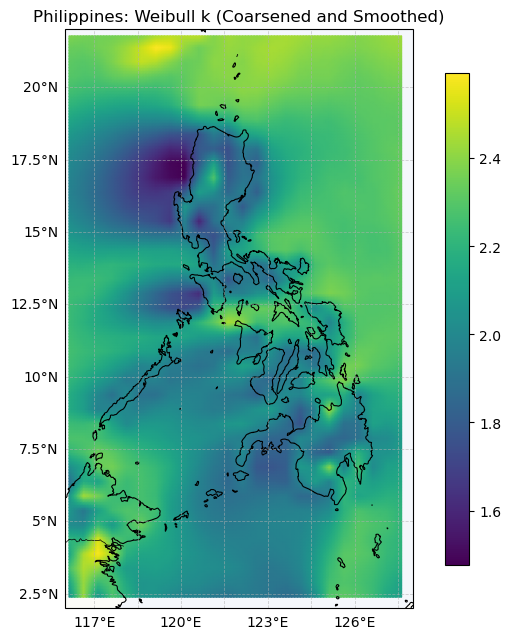

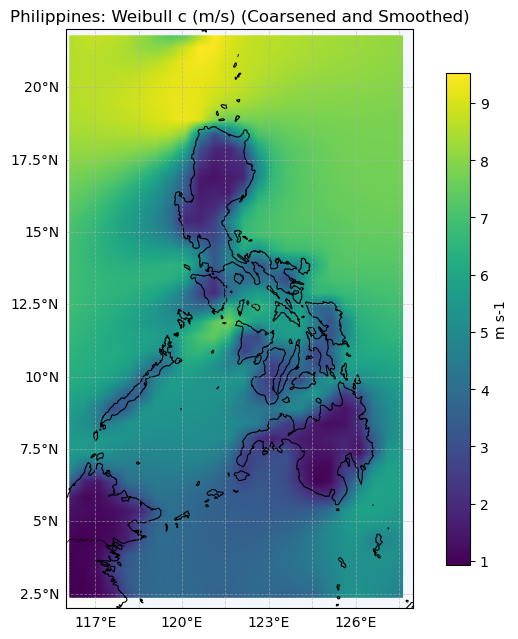

In [12]:
k_s = smooth_da(k_da, dlat=0.1, dlon=0.1)
c_s = smooth_da(c_da, dlat=0.1, dlon=0.1)

plot_map(
    k_s,
    'Philippines: Weibull k (Coarsened and Smoothed)',
    '../reports/figures/weibull_k_smoothed.png'
)

plot_map(
    c_s,
    'Philippines: Weibull c (m/s) (Coarsened and Smoothed)',
    '../reports/figures/weibull_c_smoothed.png'
)

## Check: Select Grid Point & Plot Histogram and Fitted Weibull PDF

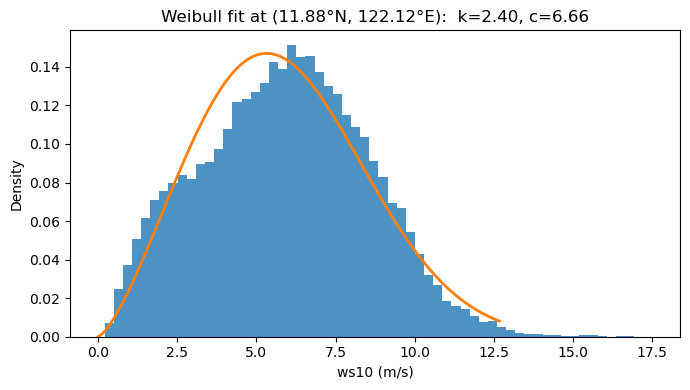

In [13]:
# pick a representative point near middle of the domain (coarsened grid)
lat0 = float(ws_c.latitude.values[len(ws_c.latitude)//2])
lon0 = float(ws_c.longitude.values[len(ws_c.longitude)//2])

x = ws_c.sel(latitude=lat0, longitude=lon0, method="nearest").values
x = x[np.isfinite(x)]
x = x[x > 0.2]

k, loc, c = weibull_min.fit(x, floc=0.0)

plt.figure(figsize=(7,4))
plt.hist(x, bins=60, density=True, alpha=0.8)

xx = np.linspace(0, np.percentile(x, 99.5), 250)
plt.plot(xx, weibull_min.pdf(xx, k, loc=0.0, scale=c), linewidth=2)

plt.title(f"Weibull fit at ({lat0:.2f}°N, {lon0:.2f}°E):  k={k:.2f}, c={c:.2f}")
plt.xlabel("ws10 (m/s)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("../reports/figures/weibull_fit_example.png", dpi=250)
plt.show()


## Site Screening Tables

### Top 20 Annual Mean

In [14]:
top_mean = (
    mean_ws.to_dataframe(name="mean_ws10")
    .reset_index()
    .sort_values("mean_ws10", ascending=False)
    .head(20)
)

top_mean


,latitude,longitude,number,mean_ws10
10,21.875,121.125,0,8.458588
33,21.375,120.625,0,8.427235
34,21.375,121.125,0,8.352536
57,20.875,120.625,0,8.325583
152,18.875,120.125,0,8.296281
56,20.875,120.125,0,8.252000
128,19.375,120.125,0,8.208770
58,20.875,121.125,0,8.197367
81,20.375,120.625,0,8.192157
104,19.875,120.125,0,8.189152


In [15]:
top_mean.to_csv("../reports/top20_mean_ws10.csv", index=False)

### Top 20 Weibull c (Resource Strength)

In [16]:
top_c = (
    c_da.to_dataframe(name="weibull_c")
    .reset_index()
    .sort_values("weibull_c", ascending=False)
    .head(20)
)

top_c


,latitude,longitude,weibull_c
10,21.875,121.125,9.550901
33,21.375,120.625,9.514560
34,21.375,121.125,9.431588
57,20.875,120.625,9.393480
152,18.875,120.125,9.341389
56,20.875,120.125,9.305655
58,20.875,121.125,9.251347
128,19.375,120.125,9.245474
81,20.375,120.625,9.236656
80,20.375,120.125,9.228904


In [17]:
top_c.to_csv("../reports/top20_weibull_c.csv", index=False)

### Top 20 by Lowest k (Most Variable) and Highest k (Most Consistent)

In [23]:
top_k_high = (
    k_da.to_dataframe(name="weibull_k")
    .reset_index()
    .sort_values("weibull_k", ascending=False)
    .head(20)
)

top_k_low = (
    k_da.to_dataframe(name="weibull_k")
    .reset_index()
    .sort_values("weibull_k", ascending=True)
    .head(20)
)

In [24]:
top_k_high

,latitude,longitude,weibull_k
30,21.375,119.125,2.592780
866,3.875,117.125,2.582517
31,21.375,119.625,2.562695
842,4.375,117.125,2.537259
9,21.875,120.625,2.511770
29,21.375,118.625,2.502432
53,20.875,118.625,2.490650
8,21.875,120.125,2.481091
54,20.875,119.125,2.463146
889,3.375,116.625,2.458200


In [20]:
top_k_low

,latitude,longitude,weibull_k
224,17.375,120.125,1.477779
248,16.875,120.125,1.482273
223,17.375,119.625,1.492780
247,16.875,119.625,1.504987
246,16.875,119.125,1.556025
222,17.375,119.125,1.574576
321,15.375,120.625,1.595174
199,17.875,119.625,1.598901
441,12.875,120.625,1.615760
200,17.875,120.125,1.618398


In [25]:
top_k_high.to_csv("../reports/top20_weibull_k_high.csv", index=False)
top_k_low.to_csv("../reports/top20_weibull_k_low.csv", index=False)

## Save k/c Maps to NetCDF file

In [26]:
weibull_ds = xr.Dataset({"weibull_k": k_da, "weibull_c": c_da})
weibull_ds.to_netcdf("../data/interim/weibull_kc_coarsened_2019_2023.nc")
print("Saved:", "../data/interim/weibull_kc_coarsened_2019_2023.nc")

Saved: ../data/interim/weibull_kc_coarsened_2019_2023.nc


## Plot Top Mean, k (low and high), and c

In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

def plot_map_with_points(
    da,
    points_df,
    title,
    out_png,
    extent=(116, 128, 2, 22),
    add_rank_labels=True
):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(11, 6.5))
    ax = plt.axes(projection=proj)
    ax.set_extent(extent, crs=proj)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.1)

    gl = ax.gridlines(crs=proj, draw_labels=True, linewidth=0.6,
                      linestyle="--", alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    im = ax.pcolormesh(
        da["longitude"], da["latitude"], da.values,
        transform=proj, shading="gouraud"
    )
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
    cb.set_label(da.attrs.get("units", ""))

    # Red triangles
    ax.scatter(
        points_df["longitude"],
        points_df["latitude"],
        color="red",
        marker="^",
        s=90,
        edgecolor="black",
        linewidth=0.6,
        transform=proj,
        zorder=5
    )

    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=250)
    plt.show()
    plt.close(fig)


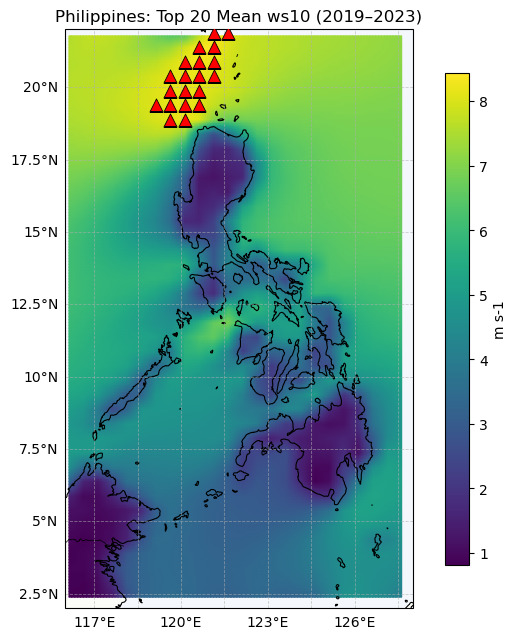

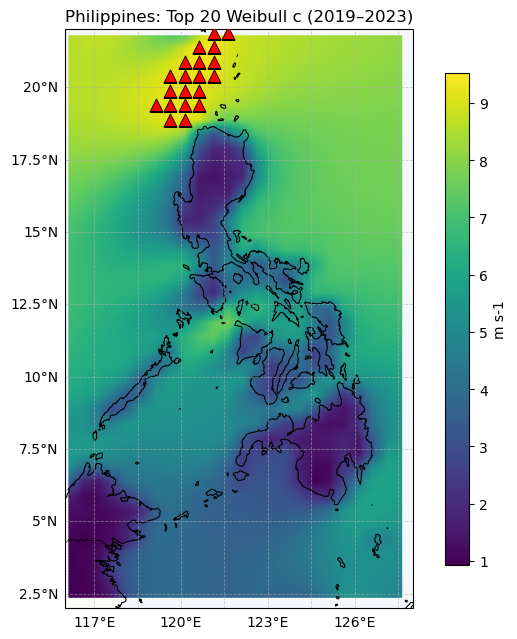

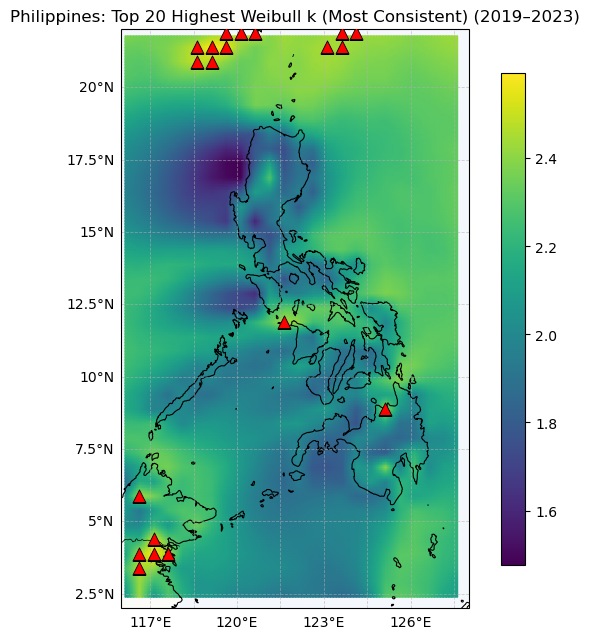

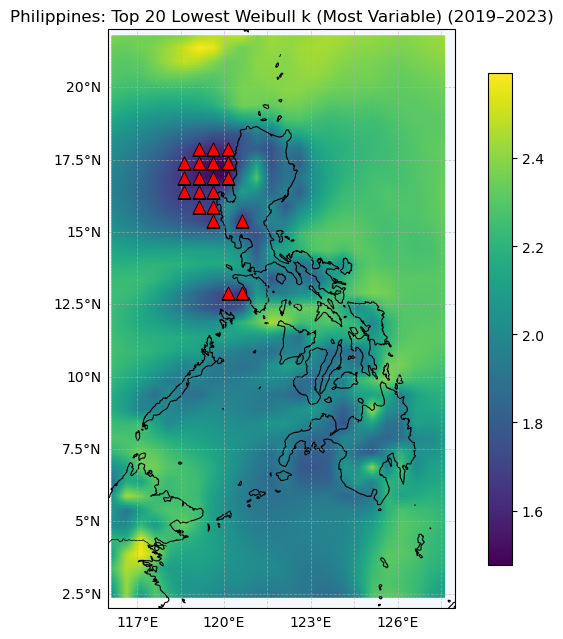

In [30]:
# Smooth the background fields for nicer visuals
mean_s = smooth_da(mean_ws, dlat=0.1, dlon=0.1)
c_s    = smooth_da(c_da,   dlat=0.1, dlon=0.1)
k_s    = smooth_da(k_da,   dlat=0.1, dlon=0.1)

plot_map_with_points(
    mean_s, top_mean,
    "Philippines: Top 20 Mean ws10 (2019–2023)",
    "../reports/figures/top20_mean_ws10_triangles.png",
)

plot_map_with_points(
    c_s, top_c,
    "Philippines: Top 20 Weibull c (2019–2023)",
    "../reports/figures/top20_weibull_c_triangles.png",
)

plot_map_with_points(
    k_s, top_k_high,
    "Philippines: Top 20 Highest Weibull k (Most Consistent) (2019–2023)",
    "../reports/figures/top20_weibull_k_high_triangles.png",
)

plot_map_with_points(
    k_s, top_k_low,
    "Philippines: Top 20 Lowest Weibull k (Most Variable) (2019–2023)",
    "../reports/figures/top20_weibull_k_low_triangles.png",
)


## Results and Discussion

### 1. Wind Climatology (2019–2023)

The multi-year ERA5 analysis (2019–2023) shows clear spatial variability in wind resource across the Philippine domain. 

- Highest annual mean wind speeds are predominantly located offshore, particularly along the western seaboard and northern sections of Luzon.
- Seasonal variability is evident, with stronger winds typically associated with monsoon transitions and enhanced synoptic forcing.
- Inland and mountainous regions exhibit lower mean wind speeds but higher spatial heterogeneity.

These results indicate that offshore and coastal zones provide the strongest baseline wind resource potential.

---

### 2. Extreme Percentiles (P95 and P99)

High-percentile wind speeds (P95 and P99) reveal regions exposed to stronger episodic wind events.

- P99 values highlight offshore corridors and northern maritime zones as areas of frequent strong-wind occurrences.
- Inland regions generally exhibit lower extreme percentiles, although localized topographic enhancement may occur.

While percentiles describe the upper tail behavior, they do not fully characterize the entire wind distribution or rare-event risk.

---

### 3. Weibull Distribution Parameters

The Weibull distribution was fitted at each grid cell (coarsened resolution) to characterize the full wind-speed distribution.

#### Scale Parameter (c)
- Regions with the highest Weibull scale parameter (c) correspond closely with areas of highest mean wind speed.
- High-c zones indicate strong overall wind resource and favorable energy production potential.

#### Shape Parameter (k)
- Higher k values (k > ~2) indicate more consistent and stable wind regimes.
- Lower k values reflect greater variability and stronger tail behavior.
- Offshore areas generally show moderate-to-high k values, suggesting relatively steady wind regimes suitable for wind energy development.

Together, the (k, c) parameter maps provide a more complete representation of wind resource quality than mean wind speed alone.

---

### 4. Site Screening

Top-20 site rankings based on:
- Mean wind speed,
- Weibull scale parameter (c),
- High and low Weibull shape parameter (k),

demonstrate spatial clustering of high-resource zones offshore and in exposed coastal regions.

However, locations with high wind resource (high mean and high c) may also exhibit increased variability (lower k), which could affect turbine loading and operational stability.

---

### 5. Implications

This multi-year analysis suggests:

- Offshore and coastal regions exhibit the strongest wind resource potential.
- Weibull parameters provide essential insight into both wind magnitude (c) and consistency (k).
- Percentiles highlight strong-wind exposure but should be complemented with distribution-based modeling.
- Combined resource and variability metrics are necessary for robust wind farm siting decisions.

Further work should include:
- Hub-height extrapolation,
- Wind power density estimation,
- Extreme return-level analysis (e.g., 10-year, 50-year wind speeds),
- and comparison with high-resolution regional models.

